# Månatliga telekom-KPI:er: dataanvändningsstaplar med ARPU- och kundbortfallslinjer (PROC GBARLINE)

## Sammanfattning

Den här notebooken använder **PROC GBARLINE** för att kombinera ett vertikalt stapeldiagram över månatlig mobildataanvändning med överlagrade linjediagram för ARPU, kundbortfall och supportärenden — den klassiska tvåaxlade KPI-instrumentpanelen en telekomanalytiker bygger för att se om ökande användning verkligen omsätts i intäkter och kundlojalitet. Den genererar syntetiska per-abonnent-poster direkt i koden och använder sedan BAR- och LINE-satserna med undergrupper, anpassade högeraxlar, referenssymboler och förklaringar.

## Datakällor

**Dataset: `telco_kpi`** — syntetiska poster per abonnent och månad (4 månader x 3 abonnemangstyper x 8 abonnenter = 96 rader), genererade direkt i koden med `call streaminit(20260531)`. Panelen hålls vid 96 rader så att den ryms bekvämt inom 100-observationsgränsen i olicensierat läge, vilket lämnar varje månad och abonnemangstyp fullt representerad.

| Variabel | Typ | Beskrivning |
|----------|------|-------------|
| `month`  | Char | Kalendermånad (jan–apr) |
| `plan`   | Char | Abonnemangstyp: Kontantkort, Abonnemang, Familj |
| `data_gb`| Num  | Månatlig mobildata förbrukad, i GB (gammafördelad, med en mild säsongsuppgång och långsam tillväxt) |
| `arpu`   | Num  | Genomsnittlig intäkt per användare, i USD (stiger med abonnemangstyp och över månaderna) |
| `churn`  | Num  | Månatlig kundbortfallsflagga (0/1, Bernoulli; högre tidigt under perioden och för lägre abonnemangstyper) |
| `tickets`| Num  | Öppnade supportärenden (Poisson-antal) |

# Månatliga telekom-KPI:er med PROC GBARLINE

Telekomoperatörer lever och dör med en handfull månatliga KPI:er: hur mycket **data** abonnenterna förbrukar, den **ARPU** (genomsnittlig intäkt per användare) den förbrukningen genererar, hur många kunder som **lämnar** (churn), och den **supportärende**-belastning som ligger bakom allt detta. Dessa mått lever på mycket olika skalor — gigabyte, dollar och små antal — så att plotta dem på en enda responsaxel döljer berättelsen.

`PROC GBARLINE` är byggd för precis detta: den ritar ett vertikalt **stapel**-diagram mot vänsteraxeln och lägger ett eller flera **linje**-diagram ovanpå mot en oberoende högeraxel. I den här notebooken bygger vi en instrumentpanel för användning mot intäkt, och lägger sedan gradvis till abonnemangsnivå-undergrupper, en anpassad högeraxel och flerlinjeöverlägg.

## Steg 1 — Generera syntetisk abonnent-månadsdata

Datasteget nedan skapar en realistisk panel: 4 månader (jan–apr) över 3 abonnemangstyper (Kontantkort, Abonnemang, Familj) med 8 abonnenter vardera, totalt 96 rader. Vi initierar slumptalsgeneratorn med `call streaminit` för reproducerbarhet och drar varje KPI från en domänlämplig fördelning:

- **Dataanvändning** från en gammafördelning med en mild säsongsuppgång och långsam tillväxt månad för månad.
- **ARPU** som stiger med abonnemangstyp och över månaderna, med normalfördelat brus.
- **Kundbortfall** som en Bernoulli-flagga som är högre tidigt under perioden och för billigare abonnemangstyper.
- **Supportärenden** som Poisson-antal, något tyngre tidigt.

Inga externa filer läses in — allt är självständigt, och panelen med 96 rader håller sig inom den olicensierade gränsen på 100 observationer så att varje månad och abonnemangstyp renderas.

In [1]:
data telco_kpi;
    CALL streaminit(20260531);
    LÄNGD month $3 plan $12;
    FÄLT mname[4] $3 _temporary_
        ('Jan' 'Feb' 'Mar' 'Apr');
    GÖR mi = 1 TILL 4;
        month = mname[mi];
        /* mild säsongsuppgång och långsam datatillväxt */
        season = 1 + 0.10*sin((mi-1)/12*2*3.14159);
        GÖR plan_i = 1 TILL 3;
            OM plan_i = 1 SÅ plan = 'Kontantkort';
            ANNARS OM plan_i = 2 SÅ plan = 'Abonnemang';
            ANNARS plan = 'Familj';
            GÖR rep = 1 TILL 8;
                /* månatligen förbrukad mobildata (GB) */
                data_gb = rand('gamma', 4) * 3 * season
                          + (mi * 0.4);
                /* genomsnittlig intäkt per användare ($) */
                arpu = 28 + 6*plan_i + rand('normal', 0, 4)
                       + mi*0.3;
                /* månatlig kundbortfallsflagga, högre tidigt på året */
                churn = rand('bernoulli',
                             0.18 - 0.03*plan_i + 0.02*(4-mi));
                /* öppnade supportärenden */
                tickets = rand('poisson', 1.6 + 0.15*(4-mi));
                UTDATA;
            SLUT;
        SLUT;
    SLUT;
    TA_BORT mi plan_i rep season mname:;
KÖR;


NOTE: DATA telco_kpi


NOTE: Wrote telco_kpi (96 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Steg 2 — Kärninstrumentpanelen: användningsstaplar + ARPU-linje

Det här är det kanoniska `GBARLINE`-mönstret. `BAR`-satsen ritar genomsnittlig månatlig dataanvändning (`SUMVAR=data_gb TYPE=mean`), och en enda `LINE`-sats lägger genomsnittlig ARPU ovanpå på högeraxeln (`STAT=mean TYPE=join`). Vi slår på ODS Graphics och ger diagrammet en tvåradig titel. `COUTLINE=` och `WIDTH=` snyggar till staplarna.

                                         Månatlig mobildataanvändning och ARPU                                          
                                          Syntetiska KPI:er för telekomnätverk                                          




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to Månatlig mobildataanvändning och ARPU.
NOTE: Option TITLE2 changed to Syntetiska KPI:er för telekomnätverk.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


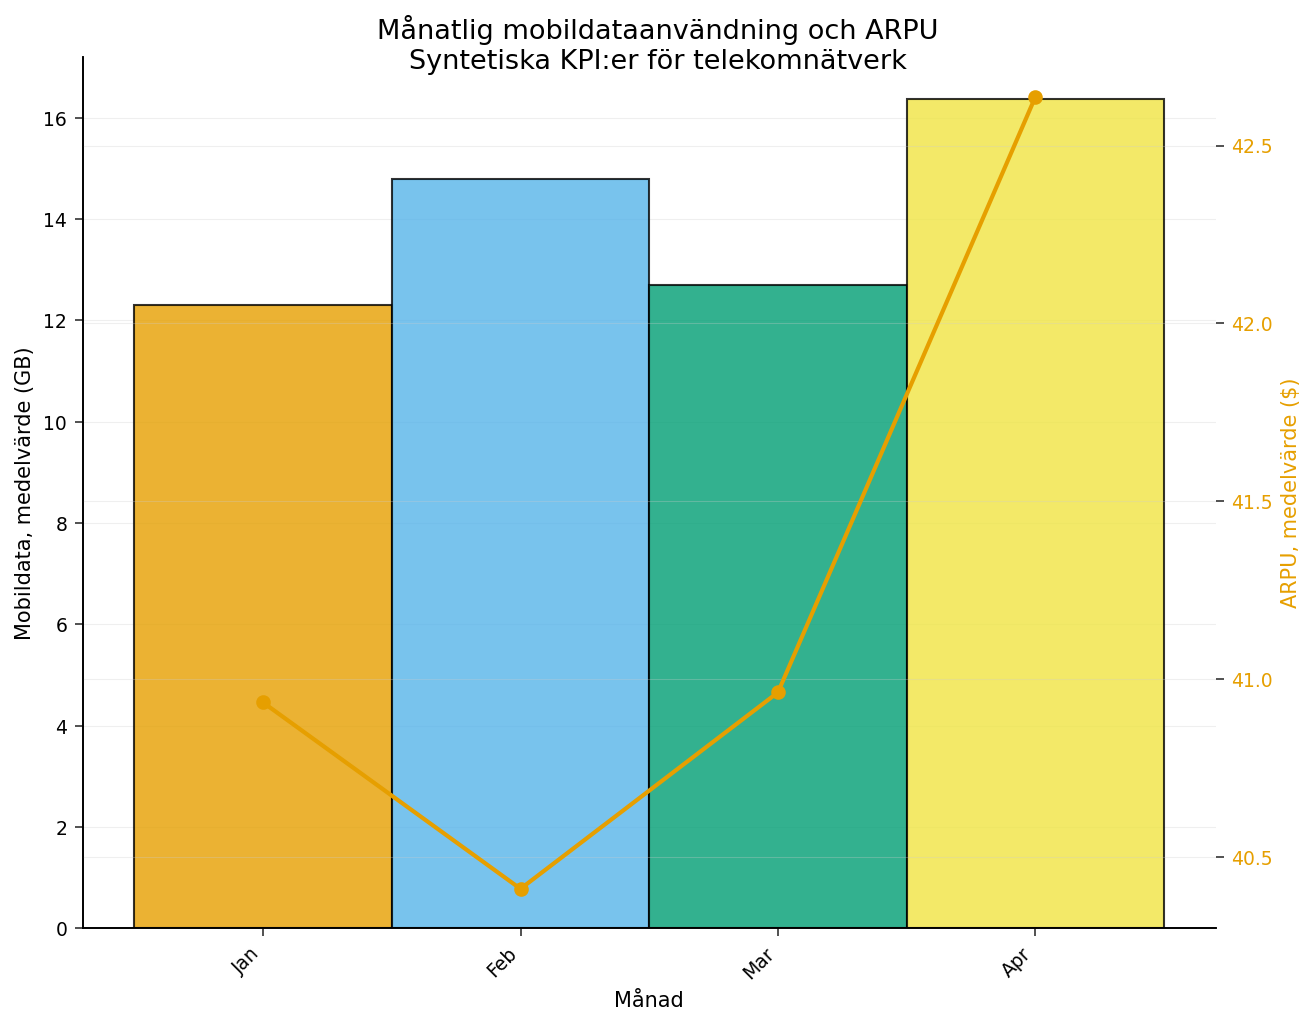

In [2]:
ODS GRAPHICS ON;
TITEL "Månatlig mobildataanvändning och ARPU";
title2 "Syntetiska KPI:er för telekomnätverk";

/* axis1 ger den kategoriska x-axelns etikett via MAXIS=; axis2/axis3 ger
   y-axelns etiketter via RAXIS= -- PROC GBARLINE härleder annars sin
   automatiska axeletikett fran det ASCII-formade variabelnamnet och
   ignorerar LABEL-satsen for det andamalet */
PROCEDUR gbarline data=telco_kpi;
    axis1 ETIKETT="Månad";
    axis2 ETIKETT="Mobildata, medelvärde (GB)";
    axis3 ETIKETT="ARPU, medelvärde ($)";
    bar month / SUMVAR=data_gb type=mean
                coutline=black WIDTH=6 maxis=axis1 raxis=axis2;
    line arpu / STAT=mean type=JOIN raxis=axis3;
    ETIKETT month="Månad" data_gb="Mobildata (GB)" arpu="ARPU ($)";
KÖR;

## Steg 3 — Dela upp användningen per abonnemangstyp, lägg på kundbortfall

Genom att ersätta `TYPE=mean` med `TYPE=sum` och lägga till `SUBGROUP=plan` staplas varje månads stapel per abonnemangstyp, så att vi kan se vilket segment som driver totalvolymen. Den överlagrade `LINE`-satsen plottar nu det månatliga **antalet** kundbortfallshändelser som ett spikdiagram (`STAT=sum TYPE=needle`) — vertikala spikar som naturligt läses som diskreta händelseantal snarare än en jämn trend.

                                Datavolym per abonnemangstyp med månatligt kundbortfall                                 
                                          Syntetiska KPI:er för telekomnätverk                                          




NOTE: Option TITLE changed to Datavolym per abonnemangstyp med månatligt kundbortfall.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


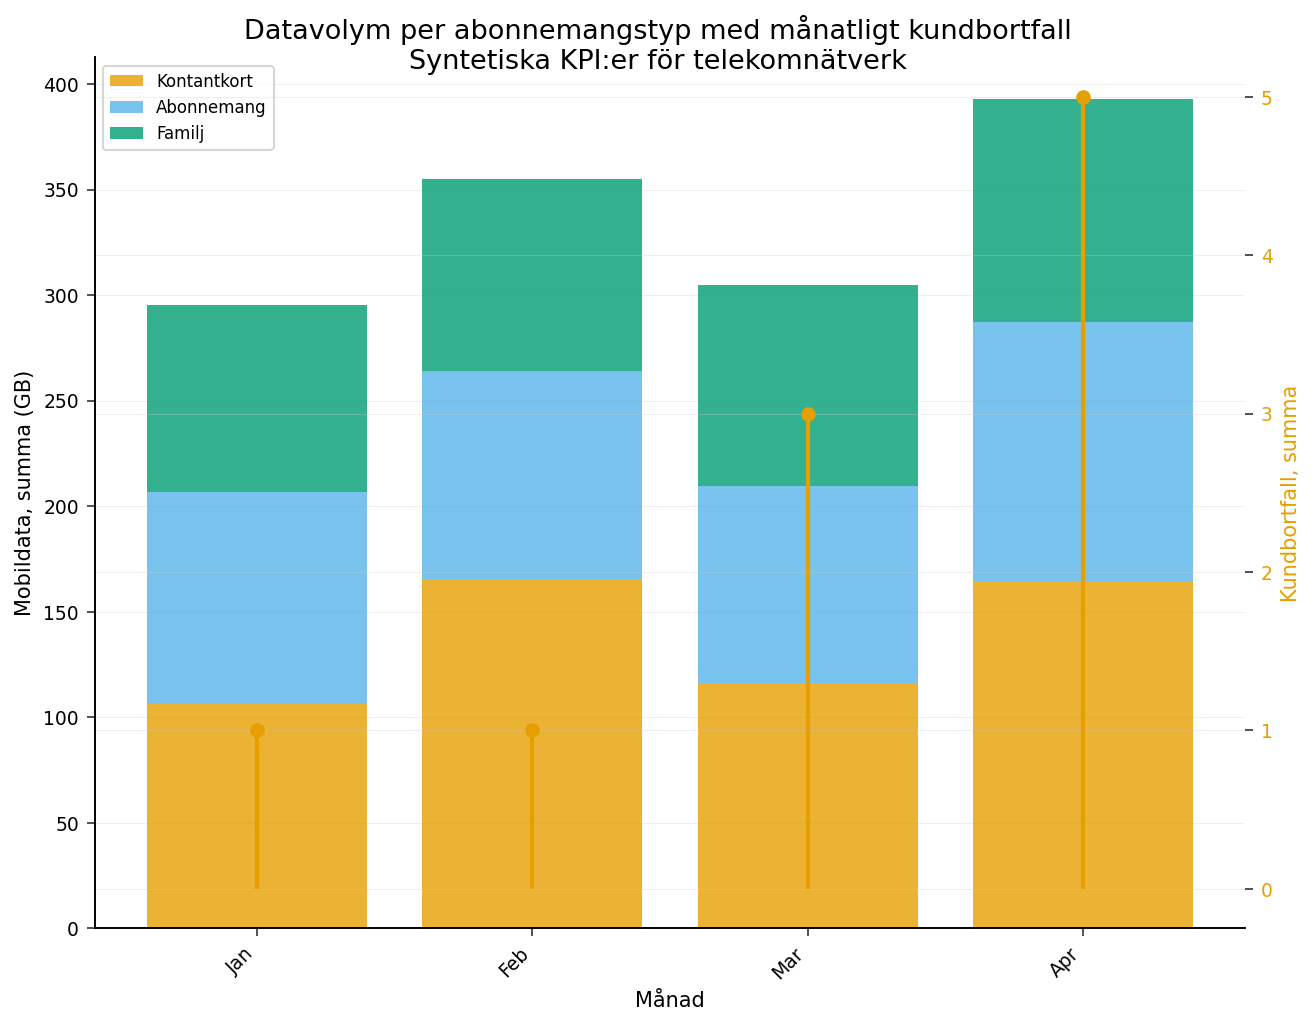

In [3]:
TITEL "Datavolym per abonnemangstyp med månatligt kundbortfall";

PROCEDUR gbarline data=telco_kpi;
    axis1 ETIKETT="Månad";
    axis2 ETIKETT="Mobildata, summa (GB)";
    axis3 ETIKETT="Kundbortfall, summa";
    bar month / SUMVAR=data_gb type=sum SUBGROUP=plan
                maxis=axis1 raxis=axis2;
    line churn / STAT=sum type=needle raxis=axis3;
    ETIKETT month="Månad" data_gb="Mobildata (GB)" plan="Abonnemangstyp" churn="Kundbortfall";
KÖR;

## Steg 4 — Styr högeraxeln och linjemarkören

För ett publiceringsklart diagram fäster vi plott-axeln (höger) till ett fast intervall med en `AXIS`-definition och märker den, och binder den sedan till linjen via `RAXIS=axis2`. En `SYMBOL`-definition ger ARPU-linjen en röd, prickad markör. Vi visar också stapelsummorna ovanför varje stapel med `OUTSIDE=sum`.

                               Total användning (staplar) mot genomsnittlig ARPU (linje)                                
                                          Syntetiska KPI:er för telekomnätverk                                          




NOTE: Option TITLE changed to Total användning (staplar) mot genomsnittlig ARPU (linje).
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


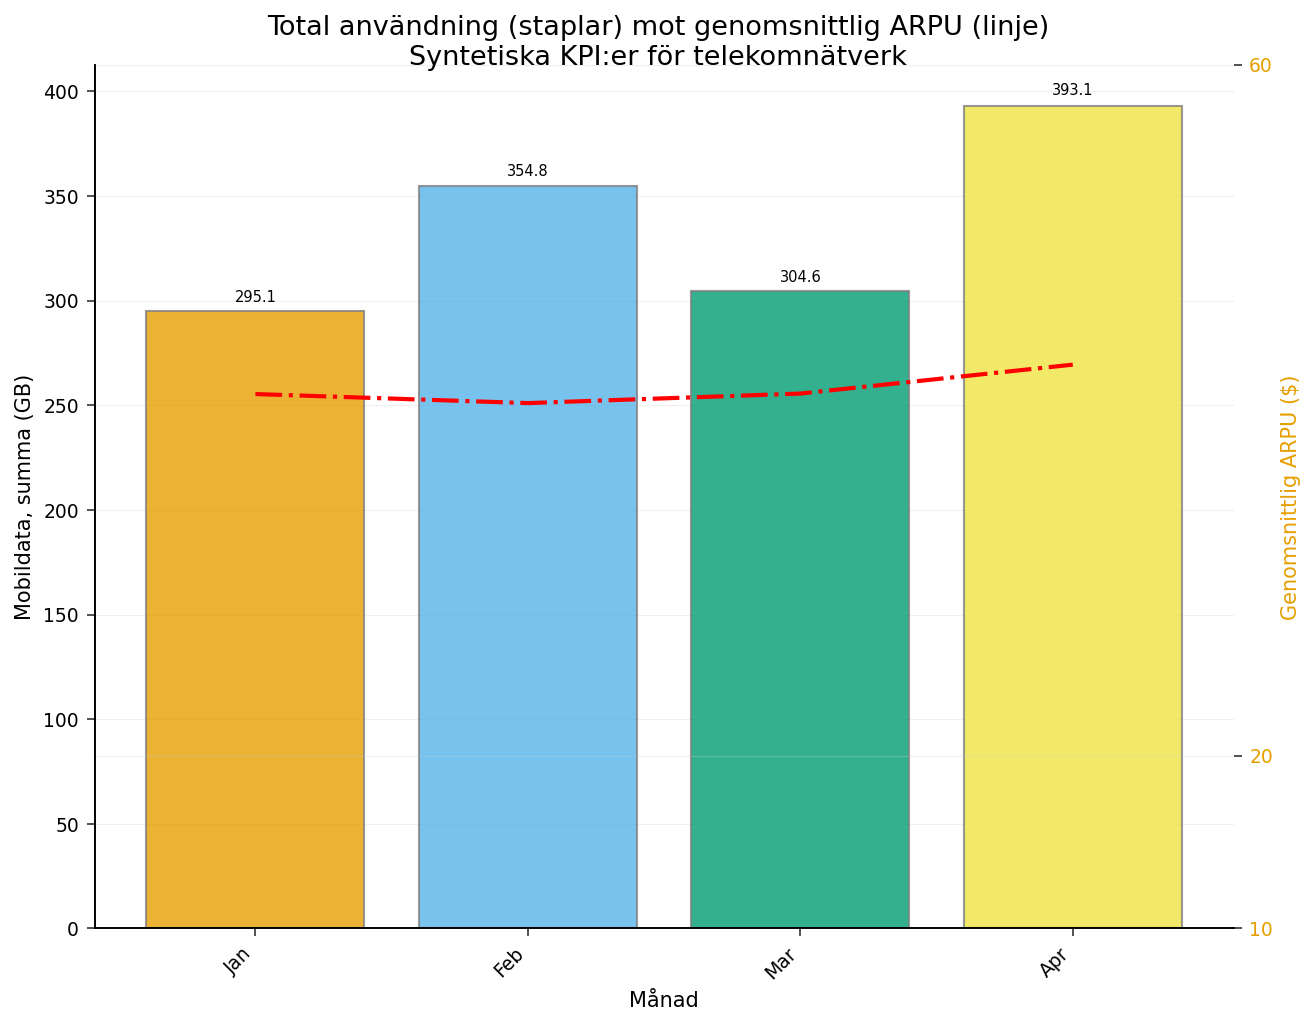

In [4]:
TITEL "Total användning (staplar) mot genomsnittlig ARPU (linje)";

PROCEDUR gbarline data=telco_kpi;
    axis1 ETIKETT="Månad";
    axis2 ORDER=(20 TILL 60 EFTER 10) ETIKETT=('Genomsnittlig ARPU ($)');
    axis3 ETIKETT="Mobildata, summa (GB)";
    symbol1 color=red INTERPOL=JOIN VALUE=dot HEIGHT=1.4;
    bar month / SUMVAR=data_gb type=sum
                outside=sum coutline=gray maxis=axis1 raxis=axis3;
    line arpu / STAT=mean type=JOIN raxis=axis2 SYMBOL=symbol1;
    ETIKETT month="Månad" data_gb="Mobildata (GB)" arpu="ARPU ($)";
KÖR;

## Steg 5 — Flera linjeöverlägg med en anpassad förklaring

`GBARLINE` accepterar mer än en `LINE`-sats, så vi kan jämföra två operativa signaler mot användningsstaplarna samtidigt: genomsnittliga supportärenden (`type=join`) och totalt kundbortfall (`type=needle`). En `LEGEND`-definition placerad längst ner dokumenterar abonnemangs-undergrupperna.

                                        Supportärenden och kundbortfallstrender                                         
                                          Syntetiska KPI:er för telekomnätverk                                          




NOTE: Option TITLE changed to Supportärenden och kundbortfallstrender.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json
NOTE: ODS Graphics is OFF.


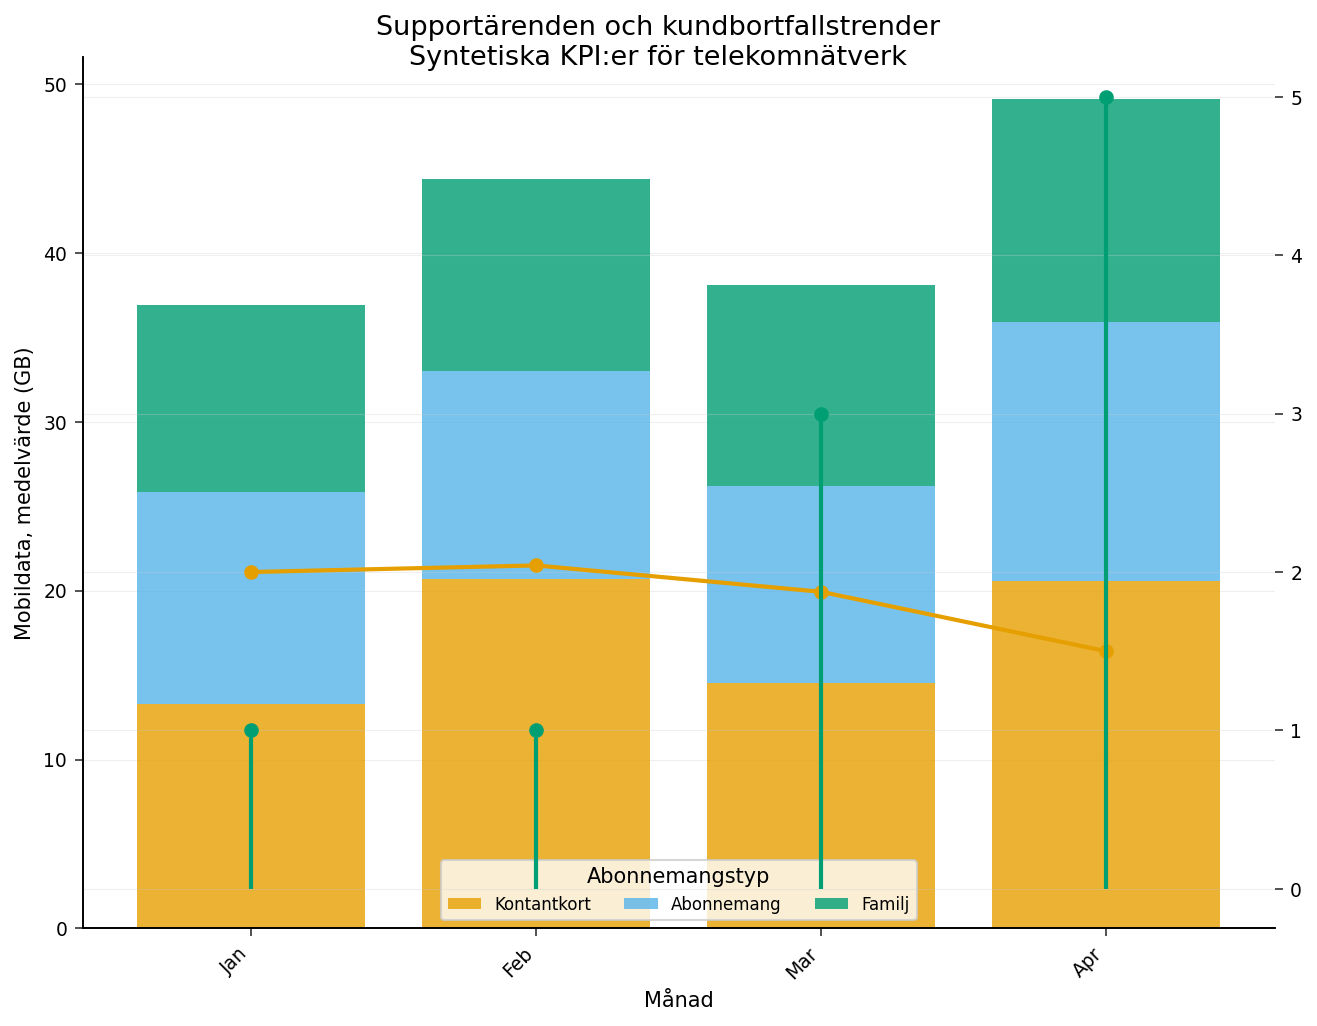

In [5]:
TITEL "Supportärenden och kundbortfallstrender";

PROCEDUR gbarline data=telco_kpi;
    axis1 ETIKETT="Månad";
    axis2 ETIKETT="Mobildata, medelvärde (GB)";
    legend1 ETIKETT=('Abonnemangstyp') position=(bottom) ACROSS=3;
    bar month / SUMVAR=data_gb type=mean SUBGROUP=plan
                legend=legend1 maxis=axis1 raxis=axis2;
    line tickets / STAT=mean type=JOIN;
    line churn / STAT=sum type=needle;
    ETIKETT month="Månad" data_gb="Mobildata (GB)" plan="Abonnemangstyp"
          tickets="Supportärenden" churn="Kundbortfall";
KÖR;

ODS GRAPHICS OFF;

## Tolkning av resultaten

Över perioden jan–apr berättar instrumentpanelen en sammanhängande telekomhistoria. **Dataanvändningen** (staplarna) är ojämn månad för månad men trendar uppåt och toppar i **april** — genomsnittlig användning stiger från cirka 12,3 GB i januari till 16,4 GB i april (Steg 2), och totalvolymen från 295 GB till 393 GB (`OUTSIDE=sum`-etiketterna i Steg 4). **ARPU-linjen** dippar något i februari och stiger sedan till sin egen apriltopp nära 42,6 USD, så operatören monetariserar i allt högre grad den extra förbrukningen i stället för att ge bort den — högeraxeln i Steg 4 är fixerad till 20–60 USD för att hålla den rörelsen läsbar.

De abonnemangsstaplade vyerna (Steg 3 och 5) avslöjar den segmentspänning som präglar operatörer med mycket kontantkort. **Kontantkort** (det orangea bandet) drar mest gigabyte totalt — omkring 553 GB över de fyra månaderna mot 415 GB för Abonnemang och 380 GB för Familj — men genererar ändå den **lägsta** genomsnittliga intäkten per användare (cirka 36 USD, mot 41 USD för Abonnemang och 47 USD för Familj). **Kundbortfallsspikarna** bekräftar var retentionsrisken finns: kundbortfallshändelser klustrar på Kontantkort- och Abonnemang-nivåerna (4 händelser vardera under perioden) och håller sig lägre för Familj (2), och de växer mot april när abonnentbasen och användningen expanderar.

Steg 5 lägger den operativa belastningen ovanpå detta: genomsnittliga **supportärenden** ligger något tyngre tidigt under perioden och avtar mot april, medan kundbortfallsspikarna toppar senare — den typ av signal ett retentionsteam bevakar. Operativt pekar det på att koncentrera retentionssatsningar på **Kontantkort**-abonnenter, som förbrukar den snabbast växande andelen datavolym samtidigt som de genererar minst intäkt och mest kundbortfall.

`PROC GBARLINE` är rätt verktyg här just för att det håller de gigabyte-skalade staplarna och de dollar-/antalsskalade linjerna på oberoende axlar, vilket låter varje KPI läsas på sina egna villkor samtidigt som de delar den månatliga tidsaxeln.